Regressão linear SEM aplicar nenhuma técnica de data augmentation.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.over_sampling import SMOTE

In [33]:
df = pd.read_csv('data/wsales.csv')

FEATURES_NUM = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
FEATURE_BIN = 'Holiday_Flag'
FEATURE_CAT = 'Store'

store_dummies = pd.get_dummies(df['Store'], prefix='Store', drop_first=True, dtype=float)

X = pd.concat([df[[FEATURE_BIN] + FEATURES_NUM], store_dummies], axis=1)
y = df['Weekly_Sales'].values

print(X.shape, y.shape)


(6435, 49) (6435,)


In [34]:
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_orig[FEATURES_NUM])
X_test_num = scaler.transform(X_test_orig[FEATURES_NUM])

X_train_final = np.hstack([X_train_orig[[FEATURE_BIN]].values, X_train_num, X_train_orig[store_dummies.columns].values])
X_test_final = np.hstack([X_test_orig[[FEATURE_BIN]].values, X_test_num, X_test_orig[store_dummies.columns].values])

In [36]:
model = LinearRegression()
model.fit(X_train_final, y_train_orig)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 72763.84, -14503.67, -19532.38,..., -848745.18,-1000570.85, -656298.79]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.403e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](49,)","[83.39,77.42,71.94,..., 2.95, 2.36, 0.34]"


In [37]:
y_pred = model.predict(X_test_final)

mse = mean_squared_error(y_test_orig, y_pred)
mae = mean_absolute_error(y_test_orig, y_pred)
r2 = r2_score(y_test_orig, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.4f}')

MSE: 25498969757.07
MAE: 91043.93
R²: 0.9208


Gráfico: predito vs real.

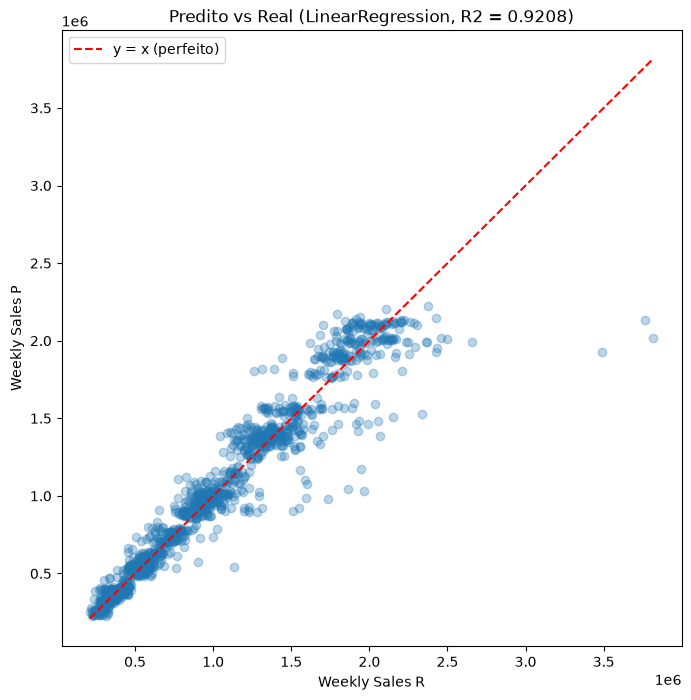

In [39]:
import matplotlib.pyplot as plt

# Recalcula localmente para evitar conflito com variáveis sobrescritas em etapas posteriores.
y_true_plot = y_test_orig
y_pred_plot = model.predict(X_test_final)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_plot, y_pred_plot, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='y = x (perfeito)')
plt.xlabel('Weekly Sales R')
plt.ylabel('Weekly Sales P')
plt.title(f'Predito vs Real (LinearRegression, R2 = {r2_score(y_true_plot, y_pred_plot):.4f})')
plt.legend()
plt.show()

Inserir SMOTE

1. Discretizar o alvo em classes (bins de largura igual; ajuste para o SMOTE funcionar).

In [ ]:
edges = np.linspace(y_train_orig.min(), y_train_orig.max(), 11)
y_class_train = np.clip(np.digitize(y_train_orig, edges) - 1, 0, 9).astype(int)

y_class_train[y_class_train == 7] = 6
y_class_train[y_class_train == 8] = 7
y_class_train[y_class_train == 9] = 7

print('Contagem por classe (0-7, treino):', np.bincount(y_class_train))

Contagem por classe (0-7): [1697 1367 1270 1049  668  314   58   12]


2. Definir máscara de classes raras para aplicar SMOTE.

In [ ]:
mask = y_class_train >= 5
mask_middle = ~mask
print('Na máscara (altas, treino):', mask.sum(), '| meio:', mask_middle.sum())

Na máscara (altas): 384 | meio: 6051


3. Aplicar SMOTE com as features contínuas padronizadas.

In [ ]:
X_mask_num = X_train_orig.loc[mask, FEATURES_NUM].values
scaler_smote = StandardScaler()
X_mask_scaled = scaler_smote.fit_transform(X_mask_num)

class_counts = np.bincount(y_class_train[mask])
valid_counts = class_counts[class_counts > 0]
min_count = valid_counts.min() if len(valid_counts) > 0 else 0

if min_count > 1:
    k = min(3, min_count - 1)
    smote = SMOTE(k_neighbors=k, random_state=42)
    X_smote_scaled, y_class_smote = smote.fit_resample(X_mask_scaled, y_class_train[mask])
else:
    X_smote_scaled = X_mask_scaled.copy()
    y_class_smote = y_class_train[mask].copy()

X_smote_num = scaler_smote.inverse_transform(X_smote_scaled)
print('X_smote_num:', X_smote_num.shape, '(antes:', X_mask_num.shape, ')')

X_smote: (942, 49) (antes: (384, 49) )


4. Definir o alvo das sintéticas por interpolação local (kNN ponderado por distância).

In [ ]:
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors

knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(X_mask_scaled, y_train_orig[mask])
y_smote = knn.predict(X_smote_scaled)

orig_scaled_by_hash = {}
for i in range(len(X_mask_scaled)):
    h = X_mask_scaled[i].tobytes()
    if h not in orig_scaled_by_hash:
        orig_scaled_by_hash[h] = y_train_orig[mask][i]
y_smote = np.array([
    orig_scaled_by_hash.get(r.tobytes(), v) for r, v in zip(X_smote_scaled, y_smote)
])

n_orig_mask = len(X_mask_scaled)
n_synth = len(X_smote_scaled) - n_orig_mask

if n_synth > 0:
    X_synth_scaled = X_smote_scaled[n_orig_mask:]
    y_smote_synth = y_smote[n_orig_mask:]
    y_class_synth = y_class_smote[n_orig_mask:]

    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(X_mask_scaled)
    nn_idx = nn.kneighbors(X_synth_scaled, return_distance=False).ravel()

    X_mask_fixed = X_train_orig.loc[mask, [FEATURE_BIN] + list(store_dummies.columns)].reset_index(drop=True)
    X_synth_fixed = X_mask_fixed.iloc[nn_idx].reset_index(drop=True)
    X_synth_num = pd.DataFrame(
        scaler_smote.inverse_transform(X_synth_scaled),
        columns=FEATURES_NUM,
    )
    X_synth_full = pd.concat([X_synth_fixed, X_synth_num], axis=1)[X_train_orig.columns]
else:
    y_smote_synth = np.array([])
    y_class_synth = np.array([], dtype=int)
    X_synth_full = pd.DataFrame(columns=X_train_orig.columns)

5. Combinar amostras sintéticas com amostras originais do treino.

In [ ]:
X_final = pd.concat([X_train_orig.reset_index(drop=True), X_synth_full.reset_index(drop=True)], axis=0, ignore_index=True)
y_final = np.hstack([y_train_orig, y_smote_synth])
y_final_class = np.hstack([y_class_train, y_class_synth]).astype(int)
print('X_final:', X_final.shape, '| y_final:', y_final.shape)

X_final: (6993, 49) | y_final: (6993,)


In [ ]:
X_final


array([[ 0.   , 52.33 ,  2.886, ...,  0.   ,  0.   ,  0.   ],
       [ 1.   , 60.14 ,  3.236, ...,  0.   ,  0.   ,  0.   ],
       [ 0.   , 47.96 ,  3.112, ...,  0.   ,  0.   ,  0.   ],
       ...,
       [ 0.   , 54.47 ,  4.   , ...,  0.   ,  0.   ,  1.   ],
       [ 0.   , 56.47 ,  3.969, ...,  0.   ,  0.   ,  1.   ],
       [ 0.   , 58.85 ,  3.882, ...,  0.   ,  0.   ,  1.   ]],
      shape=(6993, 49))

6. Manter conjunto de teste fixo e preparar treino aumentado.

In [ ]:
X_train = X_final.copy()
y_train = y_final.copy()
X_test = X_test_orig.copy()
y_test = y_test_orig.copy()
print('Treino (SMOTE):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino: (5594, 49) | Teste: (1399, 49)


7. Re-escalonar e treinar.

In [ ]:
X_train_num = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_num = scaler.transform(X_test[FEATURES_NUM])
X_train_final = np.hstack([X_train[[FEATURE_BIN]].values, X_train_num, X_train[store_dummies.columns].values])
X_test_final = np.hstack([X_test[[FEATURE_BIN]].values, X_test_num, X_test[store_dummies.columns].values])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)

model.fit(X_train_final, y_train)

Treino final: (5594, 49) | Teste final: (1399, 49)


8. Avaliar.

In [ ]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 53188561885.87
MAE: 156138.27
R2: 0.9000


Inserir Mix-Up

1. Função MixUp.

In [ ]:
def mixup(X, y, alpha=0.2, n_samples=2):
    X_mix = []
    y_mix = []

    for _ in range(n_samples):
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        lam = np.random.beta(alpha, alpha)

        X_mixed = lam * X + (1 - lam) * X_shuffled
        y_mixed = lam * y + (1 - lam) * y_shuffled

        X_mix.append(X_mixed)
        y_mix.append(y_mixed)

    return np.vstack(X_mix), np.hstack(y_mix)


2. Aplicar MixUp dentro de cada grupo de classe.

In [ ]:
np.random.seed(42)

mix_rows = []
y_mix = []
cls_mix = []

for c in np.unique(y_final_class):
    idx = np.where(y_final_class == c)[0]
    if len(idx) < 2:
        continue

    X_group = X_final.iloc[idx].reset_index(drop=True)
    y_group = y_final[idx]

    for _ in range(2):
        perm = np.random.permutation(len(X_group))
        lam = np.random.beta(0.2, 0.2, size=len(X_group))[:, None]

        X_num = X_group[FEATURES_NUM].values
        X_num_perm = X_num[perm]
        X_num_mix = lam * X_num + (1 - lam) * X_num_perm

        y_mix_group = lam.ravel() * y_group + (1 - lam.ravel()) * y_group[perm]

        X_fixed = X_group[[FEATURE_BIN] + list(store_dummies.columns)].copy()
        X_mix_group = pd.concat(
            [
                X_fixed.reset_index(drop=True),
                pd.DataFrame(X_num_mix, columns=FEATURES_NUM),
            ],
            axis=1,
        )[X_final.columns]

        mix_rows.append(X_mix_group)
        y_mix.append(y_mix_group)
        cls_mix.append(np.full(len(X_mix_group), c))

if len(mix_rows) > 0:
    X_mix_df = pd.concat(mix_rows, ignore_index=True)
    y_mix_arr = np.hstack(y_mix)
    cls_mix_arr = np.hstack(cls_mix).astype(int)
else:
    X_mix_df = pd.DataFrame(columns=X_final.columns)
    y_mix_arr = np.array([])
    cls_mix_arr = np.array([], dtype=int)

X_combined = pd.concat([X_final.reset_index(drop=True), X_mix_df.reset_index(drop=True)], ignore_index=True)
y_combined = np.hstack([y_final, y_mix_arr])
y_combined_class = np.hstack([y_final_class, cls_mix_arr]).astype(int)
print('X_combined:', X_combined.shape, '| y_combined:', y_combined.shape)

X_combined: (13986, 49) | y_combined: (13986,)


In [ ]:
X_combined


array([[ 0.        , 46.38762924,  2.74419615, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.88132588, 47.17523258,  2.73965871, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 51.49654477,  2.52859692, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , 36.06544508,  3.25712885, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 36.88083627,  3.07459767, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 40.00175809,  2.87117113, ...,  0.        ,
         0.        ,  0.        ]], shape=(13986, 49))

3. Re-divisão em treino/teste.

In [ ]:
X_train = X_combined.copy()
y_train = y_combined.copy()
X_test = X_test_orig.copy()
y_test = y_test_orig.copy()
print('Treino (MixUp):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino: (11188, 49) | Teste: (2798, 49)


4. Re-escalonar e treinar.

In [ ]:
X_train_num = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_num = scaler.transform(X_test[FEATURES_NUM])
X_train_final = np.hstack([X_train[[FEATURE_BIN]].values, X_train_num, X_train[store_dummies.columns].values])
X_test_final = np.hstack([X_test[[FEATURE_BIN]].values, X_test_num, X_test[store_dummies.columns].values])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)

model.fit(X_train_final, y_train)

Treino final: (11188, 49) | Teste final: (2798, 49)


5. Avaliar.

In [ ]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 52049280952.45
MAE: 153414.97
R2: 0.8953


Inserir ruído gaussiano

1. Função para adicionar ruído gaussiano.

In [ ]:
def add_gaussian_noise(X, mean=0, stddev=0.1):
    noise = np.random.normal(mean, stddev, X.shape)
    return X + noise


2. Aplicar ruído apenas nas features contínuas (σ = 10% do desvio padrão de cada feature).

In [ ]:
X_noisy = []
y_noisy = []

sigma_feat = X_combined[FEATURES_NUM].std(axis=0).values * 0.10

for c in np.unique(y_combined_class):
    idx = y_combined_class == c
    X_group = X_combined.loc[idx].copy()
    y_group = y_combined[idx]

    X_group.loc[:, FEATURES_NUM] = add_gaussian_noise(X_group[FEATURES_NUM].values, stddev=sigma_feat)

    X_noisy.append(X_group)
    y_noisy.append(y_group)

X_final_noisy = pd.concat([X_combined] + X_noisy, ignore_index=True)
y_final_noisy = np.hstack([y_combined] + y_noisy)
print('X_final_noisy:', X_final_noisy.shape, '| y_final_noisy:', y_final_noisy.shape)

X_final_noisy: (27972, 49) | y_final_noisy: (27972,)


In [ ]:
X_final_noisy


array([[ 0.        , 46.38762924,  2.74419615, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.88132588, 47.17523258,  2.73965871, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 51.49654477,  2.52859692, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , 37.6155638 ,  3.20730383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 39.91033516,  3.064251  , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 41.71246503,  2.90490137, ...,  0.        ,
         0.        ,  0.        ]], shape=(27972, 49))

3. Re-divisão em treino/teste.

In [ ]:
X_train = X_final_noisy.copy()
y_train = y_final_noisy.copy()
X_test = X_test_orig.copy()
y_test = y_test_orig.copy()
print('Treino (ruído):', X_train.shape, '| Teste (fixo):', X_test.shape)

Treino: (22377, 49) | Teste: (5595, 49)


4. Re-escalonar e treinar.

In [ ]:
X_train_num = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_num = scaler.transform(X_test[FEATURES_NUM])
X_train_final = np.hstack([X_train[[FEATURE_BIN]].values, X_train_num, X_train[store_dummies.columns].values])
X_test_final = np.hstack([X_test[[FEATURE_BIN]].values, X_test_num, X_test[store_dummies.columns].values])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)

model.fit(X_train_final, y_train)

Treino final: (22377, 49) | Teste final: (5595, 49)


5. Avaliar.

In [ ]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 57334298065.52
MAE: 159856.38
R2: 0.8906
